## 30-year vs 50-year mortgage
With all the talk about a 50-year mortgage, here's the tradeoff based on interest rates

In [ ]:
principal = 500000
inflation = 0.02

import math

def payments(apr_annual: float, years: int, inflation_annual: float, principal: float):
    r = apr_annual / 12.0                   # monthly interest rate
    n = years * 12                           # months
    pmt = principal * r / (1 - (1 + r) ** (-n))

    # total outlay (undiscounted)
    total_outlay = pmt * n

    # NPV of cash flows to the lender, discounted by monthly inflation
    d = inflation_annual / 12.0
    pv_payments = sum(pmt / ((1 + d) ** t) for t in range(1, n + 1))
    bank_npv = pv_payments - principal       # inflows minus initial outflow

    return pmt, total_outlay, bank_npv


def balance_after_months(apr_annual: float, years: int, principal: float, k: int) -> float:
    r = apr_annual / 12.0
    n = years * 12
    pmt = principal * r / (1 - (1 + r) ** (-n))
    return principal * (1 + r) ** k - pmt * ((1 + r) ** k - 1) / r

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


At 6.5%: payment ≈ $2,811/mo (50-yr) vs $3,154/mo (30-yr)—save $343/mo. 10-yr equity: $19 (50-yr) vs $76 (30-yr)—gap ≈ $58k.


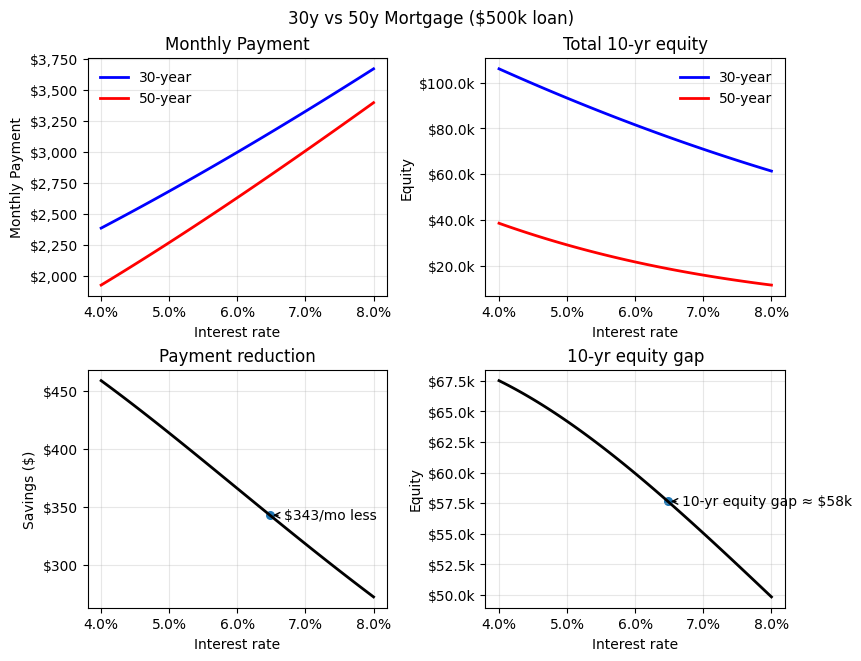

In [54]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

# --- inputs you already have ---
# principal = 500_000
# inflation = 0.03
# def payments(apr, years, inflation, principal): ...

interest_rates = [0.04 + x/2500 for x in range(101)]  # 4.00% → 8.04%

monthly_pmt_30, monthly_pmt_50 = [], []
loan_npv_30,  loan_npv_50  = [], []
equity_10yr_30 = []
equity_10yr_50 = []

for apr in interest_rates:
    p30, _, n30 = payments(apr, 30, inflation, principal)
    p50, _, n50 = payments(apr, 50, inflation, principal)
    monthly_pmt_30.append(p30)
    monthly_pmt_50.append(p50)
    loan_npv_30.append(n30)
    loan_npv_50.append(n50)
    equity_10yr_30.append((principal - balance_after_months(apr, 30, principal, 120))/1000)
    equity_10yr_50.append((principal - balance_after_months(apr, 50, principal, 120))/1000)

# Formatters
pct = FuncFormatter(lambda x, pos: f"{x*100:.1f}%")
usd = FuncFormatter(lambda y, pos: f"${y:,.0f}")
usd_k = FuncFormatter(lambda y, pos: f"${y:,.1f}k")
usd_m = FuncFormatter(lambda y, pos: f"${y:,.1f}M")


fig, axs = plt.subplots(2, 2, figsize=(8.5,6.5), sharex=False, constrained_layout=True)
axs = axs.ravel()
# top plot
axs[0].plot(interest_rates, monthly_pmt_30, 'b', lw=2, label="30-year")
axs[0].plot(interest_rates, monthly_pmt_50, 'r', lw=2, label="50-year")

axs[0].set_title("Monthly Payment")
axs[0].set_xlabel("Interest rate")
axs[0].set_ylabel("Monthly Payment")

axs[0].xaxis.set_major_formatter(pct)
axs[0].yaxis.set_major_formatter(usd)
axs[0].grid(True, alpha=0.3)
axs[0].legend(frameon=False)

# 2nd plot
axs[1].plot(interest_rates, equity_10yr_30, 'b', lw=2, label="30-year")
axs[1].plot(interest_rates, equity_10yr_50, 'r', lw=2, label="50-year")

axs[1].set_title("Total 10-yr equity")
axs[1].set_xlabel("Interest rate")
axs[1].set_ylabel("Equity")

axs[1].xaxis.set_major_formatter(pct)
axs[1].yaxis.set_major_formatter(usd_k)
axs[1].grid(True, alpha=0.3)
axs[1].legend(frameon=False)

# 3rd plot
axs[2].plot(interest_rates, [x-y for x,y in zip(monthly_pmt_30,monthly_pmt_50)], 'k', lw=2)

axs[2].set_title("Payment reduction")
axs[2].set_xlabel("Interest rate")
axs[2].set_ylabel("Savings ($)")

axs[2].xaxis.set_major_formatter(pct)
axs[2].yaxis.set_major_formatter(usd)
axs[2].grid(True, alpha=0.3)
axs[2].legend(frameon=False)

# 4th plot
axs[3].plot(interest_rates, [x-y for x,y in zip(equity_10yr_30, equity_10yr_50)], 'k', lw=2)

axs[3].set_title("10-yr equity gap")
axs[3].set_xlabel("Interest rate")
axs[3].set_ylabel("Equity")

axs[3].xaxis.set_major_formatter(pct)
axs[3].yaxis.set_major_formatter(usd_k)
axs[3].grid(True, alpha=0.3)
axs[3].legend(frameon=False)


# overall title
fig.suptitle("30y vs 50y Mortgage ($500k loan)", fontsize=12)

# Annotations
target_rate = 0.065  # 6.5%
ix = int(np.argmin(np.abs(np.array(interest_rates) - target_rate)))

# Grab values (rename if your arrays differ)
p30 = monthly_pmt_30[ix]; p50 = monthly_pmt_50[ix]
e30 = equity_10yr_30[ix]; e50 = equity_10yr_50[ix]

pay_diff = p30 - p50                # $/mo
equity_gap = e30 - e50              # $ over 10 years

# --- annotate Monthly Payment (top-left: axs[0,0]) ---
axs[2].scatter(interest_rates[ix], p30-p50, s=30)
axs[2].annotate(
    f"${pay_diff:,.0f}/mo less",
    xy=(interest_rates[ix], (p30-p50)),
    xytext=(interest_rates[ix]+0.002, (p30-p50)),
    arrowprops=dict(arrowstyle="->", lw=1),
    ha="left", va="center"
)

# --- annotate 10-yr Equity (top-right: axs[0,1]) ---
axs[3].scatter(interest_rates[ix], e30-e50, s=30)
axs[3].annotate(
    f"10-yr equity gap ≈ ${equity_gap:,.0f}k",
    xy=(interest_rates[ix], (e30-e50)),
    xytext=(interest_rates[ix]+0.002, (e30-e50)),
    arrowprops=dict(arrowstyle="->", lw=1),
    ha="left", va="center"
)

print(
    f"At {interest_rates[ix]*100:.1f}%: payment ≈ "
    f"${p50:,.0f}/mo (50-yr) vs ${p30:,.0f}/mo (30-yr)—save ${pay_diff:,.0f}/mo. "
    f"10-yr equity: ${e50:,.0f} (50-yr) vs ${e30:,.0f} (30-yr)—gap ≈ ${equity_gap:,.0f}k."
)

